# Covasim Graph Generation & Distance Comparison — Scaling Analysis

Questo notebook:
1. Genera **3 tipologie x 3 grafi = 9 grafi** da simulazioni covasim per **4 dimensioni** (N = 500, 1000, 1500, 2000):
   - **A - Random**: layer unico, mixing omogeneo (`pop_type='random'`)
   - **B - Hybrid standard**: 4 layer (household/school/work/community), struttura per età
   - **C - Hybrid household-heavy**: stessa struttura di B ma contatti household dominanti
2. Calcola embedding EDRep per ogni grafo
3. Misura tutte le distanze a coppie con **4 metriche**:
   - **EmbDistance** (distanza spettrale unmatched)
   - **w2_distance** (Wasserstein unmatched)
   - **w2_distance_classes (sex)** (Wasserstein per partizione sesso: femmina / maschio)
   - **w2_distance_classes (age)** (Wasserstein per partizione eta: 0-20 / 21-40 / 41-60 / 60+)
4. Valuta Silhouette Score, Between/Within ratio e NMI per ogni N

In [30]:
import sys
import os

# Aggiunge la root del progetto al path di Python per trovare i moduli locali
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Librerie scientifiche di base
import numpy as np
import networkx as nx          # manipolazione di grafi
import ot                      # optimal transport (distanza di Wasserstein)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# Simulatore di reti di contatto epidemiologiche
import covasim as cv

# Metriche di clustering e valutazione
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.decomposition import NMF   # fattorizzazione non-negativa per il clustering
from sklearn.cluster import KMeans

# Moduli locali del progetto di tesi
from EDRep_main.EDRep import NodeEmbedding   # embedding spettrale dei nodi
from functions import w2_distance_classes     # Wasserstein per partizioni


## Graph Generation

Usiamo **covasim** per generare reti di contatto realistiche. Ogni grafo rappresenta una popolazione di agenti con legami sociali estratti da layer distinti.

Tre tipologie strutturalmente diverse:

| Tipo | `pop_type` | Struttura | Caratteristica |
|------|------------|-----------|----------------|
| **A — Random** | `random` | layer unico `a` | mixing omogeneo, grado quasi-regolare |
| **B — Hybrid std** | `hybrid` | 4 layer h/s/w/c | struttura per eta, default covasim |
| **C — Hybrid hh** | `hybrid` | 4 layer h/s/w/c | household molto denso, cluster locali forti |

Per ciascuna tipologia generiamo **3 grafi** con seed diversi.

In [31]:
def covasim_graph(pop_size=200, seed=0, pop_type='random', contacts=None, location='italy'):
    """
    Esegue una simulazione covasim e restituisce la rete di contatto come grafo NetworkX.

    Parametri
    ---------
    pop_size : numero di agenti nella popolazione
    seed     : seme per la riproducibilita della simulazione
    pop_type : 'random' (layer unico omogeneo) o 'hybrid' 
    contacts : dizionario {layer: n_contatti} oppure None per i default di covasim
    location : paese per distribuzione demografica reale (default: 'italy')
    """
    # Parametri base della simulazione; contacts viene aggiunto solo se specificato
    kwargs = dict(pop_size=pop_size, rand_seed=seed, pop_type=pop_type,
                  location=location, verbose=0)
    if contacts is not None:
        kwargs['contacts'] = contacts

    # Creiamo ed eseguiamo la simulazione 
    sim = cv.Sim(**kwargs)
    sim.run()

    n = len(sim.people)
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Ogni layer contiene array p1 e p2 con gli indici dei nodi ai due estremi di ciascun contatto
    for layer in sim.people.contacts.values():
        edges = zip(layer['p1'].tolist(), layer['p2'].tolist())
        G.add_edges_from(edges)

    # Associamo a ogni nodo gli attributi demografici estratti dalla simulazione
    for i in range(n):
        G.nodes[i]['sex'] = int(sim.people.sex[i])    # 0 = femmina, 1 = maschio
        G.nodes[i]['age'] = float(sim.people.age[i])  # età in anni

    return G


In [32]:
POP_SIZES  = [500, 1000, 1500, 2000]  # dimensioni di grafo da confrontare
DIM        = 32    # dimensione embedding EDRep
K          = 3     # numero di cluster attesi (uno per tipologia)
SEEDS      = [0, 1, 2]  # tre seed per tipologia

GRAPH_TYPES = [
    {
        'label':    'A-Random',
        'pop_type': 'random',
        'contacts': {'a': 20},
        'desc':     'Homogeneous random mixing, single contact layer',
    },
    {
        'label':    'B-Hybrid-std',
        'pop_type': 'hybrid',
        'contacts': None,
        'desc':     'Realistic 4-layer network (household/school/work/community)',
    },
    {
        'label':    'C-Hybrid-hh',
        'pop_type': 'hybrid',
        'contacts': {'h': 8, 's': 5, 'w': 5, 'c': 5},
        'desc':     'Household-heavy: dense local clusters, sparse other layers',
    },
]

METRIC_NAMES = ['EmbDistance', 'w2_distance', 'w2_classes (sex)', 'w2_classes (age)']
GROUP_SIZE   = len(SEEDS)   # grafi per tipologia

print(f"Dimensioni da analizzare : {POP_SIZES}")
print(f"Tipi di grafo            : {[g['label'] for g in GRAPH_TYPES]}")
print(f"Totale grafi per N       : {len(GRAPH_TYPES) * len(SEEDS)}")

Dimensioni da analizzare : [500, 1000, 1500, 2000]
Tipi di grafo            : ['A-Random', 'B-Hybrid-std', 'C-Hybrid-hh']
Totale grafi per N       : 9


## Node Embeddings 

In [33]:
def node_embedding(G, dim=16, seed=42):
    """
    Calcola l'embedding EDRep per il grafo G.

    Parametri
    ---------
    G   : grafo NetworkX
    dim : dimensione dello spazio di embedding (numero di componenti spettrali)
    seed: seme numpy per la riproducibilita

    Restituisce
    -----------
    X : matrice (n_nodi x dim) con i vettori di embedding di ogni nodo
    """

    A = nx.to_scipy_sparse_array(G, format='csr')

    np.random.seed(seed)  
    
    emb = NodeEmbedding(A, dim=dim, k=1, verbose=False)
    
    return emb.X  # matrice (n_nodi x dim)



## Distance Functions

Quattro metriche per confrontare coppie di grafi a partire dai loro embedding:

EmbDistance, w2_distance (Wasserstein unmatched), w2_distance_classes (sex), w2_distance_classes (age).

Le funzioni `sex_partition` e `age_partition` suddividono le righe dell'embedding in base agli attributi nodali, restituendo una lista di sottomatrici (una per classe).


In [34]:
def EmbDistance(X, Y, distance_type='unmatched'):
    """
    Distanza tra due grafi basata sui loro embedding.

    - unmatched: confronta gli spettri delle Gram normalizzate (non richiede n1==n2).
    - matched  : norma di Frobenius della differenza delle Gram (richiede n1==n2).
    """
    n1, d1 = X.shape
    n2, d2 = Y.shape

    if d1 != d2:
        raise ValueError('The embedding matrices have different dimensions')
    if distance_type not in ['unmatched', 'matched']:
        raise ValueError('distance_type must be unmatched or matched')
    if distance_type == 'matched' and n1 != n2:
        raise ValueError('Matched distance requires same number of nodes')

    if distance_type == 'matched':
        # ||X^T X - Y^T Y||_F calcolata tramite l'identita bilineare
        Mxx = X.T @ X
        Mxy = X.T @ Y
        Myy = Y.T @ Y
        return np.sqrt(np.abs(
            np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2
        ))
    else:
        # Autovalori della Gram normalizzata per numero di nodi.
        # La norma L2 della differenza degli spettri misura la diversita strutturale.
        lam1 = np.linalg.eigvalsh(X.T @ X) / n1
        lam2 = np.linalg.eigvalsh(Y.T @ Y) / n2
        return np.linalg.norm(lam1 - lam2)


def w2_distance(emb_1, emb_2):
    """
    Distanza di Wasserstein-2 tra due grafi tramite le loro matrici di Gram.

    S = X X^T e la matrice di similarita tra tutti i nodi. Trattando i valori
    del triangolo superiore come distribuzione 1D, la Wasserstein misura quanto
    diversamente sono distribuite tali similarita nei due grafi.
    """
    # Matrice di Gram (n x n): S[i,j] = <x_i, x_j>
    S_1 = emb_1 @ emb_1.T
    S_2 = emb_2 @ emb_2.T

    # k=1 esclude la diagonale per non contare l'auto-similarita
    idx_1 = np.triu_indices_from(S_1, k=1)
    idx_2 = np.triu_indices_from(S_2, k=1)
    vals_S_1 = S_1[idx_1]
    vals_S_2 = S_2[idx_2]

    # Wasserstein-2 unidimensionale: radice del costo di trasporto ottimale
    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, p=2)**(1/2)
    return wd2


def sex_partition(G, X):
    """
    Separa le righe dell'embedding X in base all'attributo sex del nodo.
    Restituisce [X_femmine, X_maschi].
    """
    sexes = np.array([G.nodes[i]['sex'] for i in range(G.number_of_nodes())])
    return [X[sexes == 0], X[sexes == 1]]


def age_partition(G, X):
    """
    Separa le righe dell'embedding X in 4 fasce di età:
        0-20 | 21-40 | 41-60 | 60+

    Restituisce una lista di 4 sottomatrici (una per fascia).
    w2_distance_classes confrontera i blocchi corrispondenti tra due grafi.
    """
    ages = np.array([G.nodes[i]['age'] for i in range(G.number_of_nodes())])
    return [
        X[ages <= 20],                          # 0-20
        X[(ages > 20) & (ages <= 40)],          # 21-40
        X[(ages > 40) & (ages <= 60)],          # 41-60
        X[ages > 60],                           # 60+
    ]


## Separation Metrics

Per valutare quale distanza separa meglio le 3 tipologie di grafo usiamo tre metriche complementari, calcolate per tutte e 4 le distanze:
- **Silhouette Score** (`sklearn`, `metric='precomputed'`): per ogni grafo misura quanto è più vicino ai grafi della sua tipologia rispetto alle altre.
- **Between/Within ratio**: rapporto tra distanza media *inter*-tipologia e distanza media *intra*-tipologia.
- **NMI** (Normalized Mutual Information): confronta le etichette predette da `ClusterNMF` con il ground truth. 

In [35]:
def bw_ratio(D, labels):
    """
    Between/Within ratio: rapporto tra distanza media inter-gruppo e intra-gruppo.

    Valori > 1 indicano che i grafi dello stesso tipo sono mediamente piu vicini
    tra loro che ai grafi di tipo diverso. Valori piu alti = separazione migliore.
    """
    labels = np.array(labels)
    # Coppie con stessa etichetta -> distanze intra-gruppo (within)
    within  = [D[i, j] for i in range(len(labels))
                        for j in range(i + 1, len(labels)) if labels[i] == labels[j]]
    # Coppie con etichette diverse -> distanze inter-gruppo (between)
    between = [D[i, j] for i in range(len(labels))
                        for j in range(i + 1, len(labels)) if labels[i] != labels[j]]
    return np.mean(between) / np.mean(within)


## Calcolo su tutti i valori di N

Per ogni dimensione il loop:
1. Genera i 9 grafi e calcola gli embedding
2. Calcola le 4 matrici di distanza 9×9 (una per ciascuna metrica. Ogni cella $(i,j)$ contiene la distanza tra il grafo $i$ e il grafo $j$.)
3. Calcola Silhouette, BW Ratio e NMI per ciascuna metrica
4. Raccoglie i risultati in `results[N]` 

In [36]:
def NMF_kmeans(M, k):
    """
    Singola esecuzione di NMF + k-means sulla matrice M.

    Passaggi:
    1. Aggiunge alla diagonale la media degli elementi non-zero: rende M
       strettamente positiva e migliora la stabilita della NMF.
    2. Normalizza M per la sua media globale (scala i valori intorno a 1).
    3. Applica NMF con k componenti: M ~ W H, con H di forma (k, n).
       Le colonne di H^T (n x k) sono i descrittori latenti di ciascun punto.
    4. Applica k-means su H^T per assegnare ogni punto a un cluster.

    Restituisce le etichette predette e l'inerzia k-means (usata per la selezione).
    """
    n, _ = M.shape
    # Perturbazione diagonale: rende la matrice strettamente positiva
    Mt = M + np.eye(n) * np.mean(M[M.nonzero()])
    Mt = Mt / np.mean(Mt)  # normalizzazione per stabilita numerica

    Y = NMF(n_components=k, max_iter=2000, solver='mu').fit(Mt).components_

    # K-means su Y^T (n x k): ogni riga e il vettore latente di un punto
    kmeans = KMeans(n_clusters=k, n_init=10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))  # score = inerzia (negativa)


def ClusterNMF(M, k):
    """
    Clustering robusto tramite NMF + k-means con 21 ripetizioni indipendenti.

    NMF e k-means sono sensibili all'inizializzazione casuale: eseguiamo
    l'algoritmo 21 volte e teniamo il risultato con l'inerzia minima
    (cluster piu compatti nello spazio latente).
    """
    est_l, score = NMF_kmeans(M, k)  # prima esecuzione
    for _ in range(20):              # 20 ripetizioni aggiuntive
        est_l_, score_ = NMF_kmeans(M, k)
        if score_ < score:           # teniamo il risultato con inerzia minore
            score = score_
            est_l = est_l_
    return est_l

In [ ]:
results = {}

for pop_size in POP_SIZES:

    graphs       = []
    graph_labels = []
    type_labels  = []

    for t_idx, gtype in enumerate(GRAPH_TYPES):
        for seed in SEEDS:
            G = covasim_graph(pop_size=pop_size, seed=seed,
                              pop_type=gtype['pop_type'],
                              contacts=gtype['contacts'])
            graphs.append(G)
            graph_labels.append(f"{gtype['label'][:1]}-{seed}")
            type_labels.append(t_idx)

    N_graphs    = len(graphs)
    true_labels = np.array(type_labels)
    
    embeddings = [node_embedding(G, dim=DIM) for G in graphs]

    D_emb = np.zeros((N_graphs, N_graphs))
    D_w2  = np.zeros((N_graphs, N_graphs))
    D_cls = np.zeros((N_graphs, N_graphs))
    D_age = np.zeros((N_graphs, N_graphs))

    for i in range(N_graphs):
        for j in range(i + 1, N_graphs):
            D_emb[i, j] = EmbDistance(embeddings[i], embeddings[j])
            D_w2 [i, j] = w2_distance(embeddings[i], embeddings[j])
            D_cls[i, j] = w2_distance_classes(
                sex_partition(graphs[i], embeddings[i]),
                sex_partition(graphs[j], embeddings[j])
            )[0]
            D_age[i, j] = w2_distance_classes(
                age_partition(graphs[i], embeddings[i]),
                age_partition(graphs[j], embeddings[j])
            )[0]
            D_emb[j,i]=D_emb[i,j]; D_w2[j,i]=D_w2[i,j]
            D_cls[j,i]=D_cls[i,j]; D_age[j,i]=D_age[i,j]

    all_dist = list(zip(METRIC_NAMES, [D_emb, D_w2, D_cls, D_age]))


    scores     = {}
    mean_intra = {}
    mean_inter = {}

    for name, D in all_dist:
        sil  = silhouette_score(D, true_labels, metric='precomputed')
        bwr  = bw_ratio(D, true_labels)
        pred = ClusterNMF(D, k=K)
        nmi  = normalized_mutual_info_score(true_labels, pred)
        scores[name] = {'sil': round(sil, 4), 'bwr': round(bwr, 4), 'nmi': round(nmi, 4)}

        tl    = np.array(true_labels)
        intra = [D[i,j] for i in range(N_graphs)
                         for j in range(i+1, N_graphs) if tl[i] == tl[j]]
        inter = [D[i,j] for i in range(N_graphs)
                         for j in range(i+1, N_graphs) if tl[i] != tl[j]]
        mean_intra[name] = np.mean(intra)
        mean_inter[name] = np.mean(inter)


    results[pop_size] = {
        'scores':     scores,
        'mean_intra': mean_intra,
        'mean_inter': mean_inter,
    }

    df = pd.DataFrame(scores).T
    df.columns = ['Silhouette', 'BW Ratio', 'NMI']
    print(f"\n N={pop_size}:\n{df.to_string()}")



 N=500:
                  Silhouette  BW Ratio    NMI
EmbDistance           0.8456    6.6488  1.000
w2_distance           0.6756    4.2144  1.000
w2_classes (sex)      0.6090    3.4152  0.524
w2_classes (age)      0.7322    4.6687  1.000

 N=1000:
                  Silhouette  BW Ratio     NMI
EmbDistance           0.8505    8.1689  1.0000
w2_distance           0.7803    6.5832  1.0000
w2_classes (sex)      0.7354    5.4317  0.7860
w2_classes (age)      0.7985    7.0850  0.5895

 N=1500:
                  Silhouette  BW Ratio     NMI
EmbDistance           0.8580    9.6996  1.0000
w2_distance           0.8864   11.1278  1.0000
w2_classes (sex)      0.8685    9.6299  1.0000
w2_classes (age)      0.8049    6.8685  0.6137


## Come variano score con N

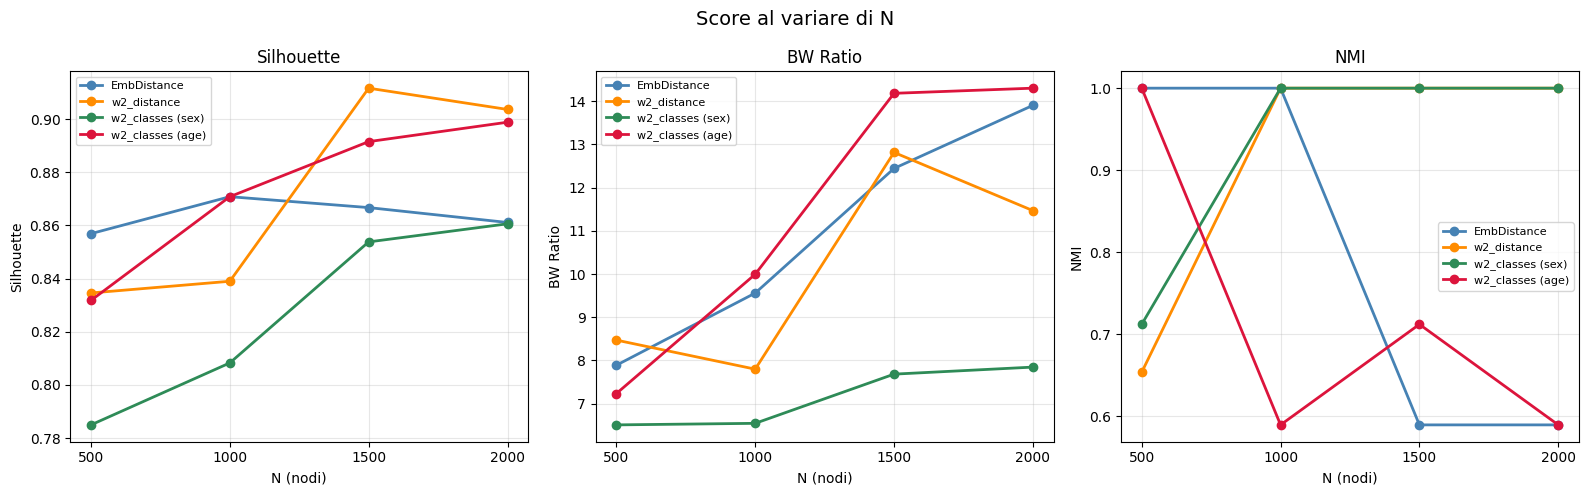

In [ ]:
COLORS       = ['steelblue', 'darkorange', 'seagreen', 'crimson']
SCORE_KEYS   = ['sil',        'bwr',       'nmi']
SCORE_LABELS = ['Silhouette', 'BW Ratio',  'NMI']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sk, sl in zip(axes, SCORE_KEYS, SCORE_LABELS):
    for mname, color in zip(METRIC_NAMES, COLORS):
        vals = [results[N]['scores'][mname][sk] for N in POP_SIZES]
        ax.plot(POP_SIZES, vals, marker='o', label=mname, color=color, linewidth=2)
    ax.set_title(sl, fontsize=12)
    ax.set_xlabel('N (nodi)')
    ax.set_ylabel(sl)
    ax.set_xticks(POP_SIZES)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Score al variare di N', fontsize=14)
plt.tight_layout()
plt.show()